# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import pathlib
import pandas as pd, numpy as np
import warnings
from db_queries import get_ids
from lsff_utils import config_utils
from lsff_utils import gbd_data
from lsff_utils.hemoglobin_distribution import hemoglobin_cdf_from_mean_sd

from tqdm.notebook import tqdm

In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "ethiopia"
vehicle = "salt"

In [5]:
intervention_scenarios = config_utils.get_config()["custom_intervention_scenarios"].get(
    location, ["intervention"]
)
intervention_scenarios

['intervention_25_nrv', 'intervention_100_nrv']

## Setup and scenarios

In [6]:
# GBD estimation year and draw set every pull below uses. Owned by gbd_data;
# shown here so a run's output records what it was built against.
gbd_data.most_recent_year(), len(gbd_data.DRAWS)

(2023, 250)

In [7]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/folate/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [8]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [9]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [10]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,value,age_start,age_end
0,1,0.0,0,125
1,2,0.0,0,125
2,3,0.0,0,125
3,4,0.0,0,125
4,5,0.0,0,125


In [11]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/folate/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.6984,intervention_25_nrv
1,1,Male,0.6984,intervention_25_nrv
2,2,Female,0.6984,intervention_25_nrv
3,2,Male,0.6984,intervention_25_nrv
4,3,Female,0.6984,intervention_25_nrv
5,3,Male,0.6984,intervention_25_nrv
6,4,Female,0.6984,intervention_25_nrv
7,4,Male,0.6984,intervention_25_nrv
8,5,Female,0.6984,intervention_25_nrv
9,5,Male,0.6984,intervention_25_nrv


In [12]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [13]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,wealth_quintile,sex,value,scenario,age_start,age_end
0,1,Female,0.6984,intervention_25_nrv,0,125
1,1,Male,0.6984,intervention_25_nrv,0,125
2,2,Female,0.6984,intervention_25_nrv,0,125
3,2,Male,0.6984,intervention_25_nrv,0,125
4,3,Female,0.6984,intervention_25_nrv,0,125
5,3,Male,0.6984,intervention_25_nrv,0,125
6,4,Female,0.6984,intervention_25_nrv,0,125
7,4,Male,0.6984,intervention_25_nrv,0,125
8,5,Female,0.6984,intervention_25_nrv,0,125
9,5,Male,0.6984,intervention_25_nrv,0,125


In [14]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [15]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  8110.649607
                               2                  7372.711095
                               3                  6970.098109
                               4                  6250.761973
                               5                  5010.316721
                                                     ...     
Male    95.0       125.000000  1                  1459.535125
                               2                  1527.072977
                               3                  1585.027440
                               4                  1677.097974
                               5                  1469.804071
Name: value, Length: 250, dtype: float64

In [16]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    ("Female", 25, 30)
].value.sum()

4867631.407035154

In [17]:
non_pregnant_pop.loc[("Female", 25, 30)][1]

592418.4734924452

In [18]:
non_pregnant_pop.loc[("Female", 25, 30)].sum()

3845516.150393378

In [19]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [20]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [21]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [22]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [23]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [24]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.reset_index()
            .assign(sex="Female")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.reset_index()
            .assign(sex="Male")
            .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [25]:
effective_coverage_intervention = (
    effective_coverage_intervention.reset_index()
    # TODO: Make this clearer. This is just reordering.
    .set_index(["sex", "age_start", "age_end", "wealth_quintile", "scenario"]).value
)

In [26]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_scenario = effective_coverage_intervention.index.get_level_values("scenario")[0]
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [27]:
effective_coverage_baseline.loc[example_tuple]

0.0

In [28]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention_25_nrv     0.6984
intervention_100_nrv    0.6984
Name: value, dtype: float64

## Pull GBD hemoglobin distributions

In [29]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

# Verify the MEIDs against get_ids
meids_df = get_ids('modelable_entity')
assert (
    meids_df.loc[
        meids_df['modelable_entity_id'] == me_ids["hemoglobin_mean"],
        'modelable_entity_name'].squeeze()
        == 'Mean Hemoglobin (g/L, elevation adjusted) - Custom')
assert (
    meids_df.loc[
        meids_df['modelable_entity_id'] == me_ids["hemoglobin_sd"],
        'modelable_entity_name'].squeeze()
        == 'Standard Deviation of Hemoglobin (g/L, survey elevation adjusted)')

# Model versions pinned explicitly. Passing version_id skips vivarium_gbd_access's
# version resolution, which goes through rotisserie -- and rotisserie has no
# rotation context for these custom MEs (RotisserieNotFoundError). Recovered from a
# warm cache, so these are whatever was current then; revisit when the round moves.
me_version_ids = {
    "hemoglobin_mean": 882457,
    "hemoglobin_sd": 882401,
}

In [30]:
hgb_mean = gbd_data.pull_modelable_entity_draws(
    me_ids["hemoglobin_mean"], location, version_id=me_version_ids["hemoglobin_mean"]
)
hgb_mean

/mnt/share/homes/zmbc/mambaforge/envs/vivarium_gates_lsff_2026_artifact/lib/python3.11/site-packages/get_draws/base/utils.py:159: RemovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  session.execute(


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    150.938586  143.623885  133.972599  148.162935   
       0.019178  0.076712    133.970319  127.477926  118.911621  131.506703   
       0.076712  0.500000    111.126555  104.207825   98.604888  107.736750   
       0.500000  1.000000    104.899234  102.179875   97.463648  101.843694   
       1.000000  2.000000    106.565626  102.661223   98.565617  102.490118   
       2.000000  5.000000    111.014111  108.298731  105.706522  107.986256   
       5.000000  10.000000   126.947658  120.795592  112.678330  124.613183   
       10.000000 15.000000   138.492498  131.780954  122.925493  135.945722   
       15.000000 20.000000   127.695758  131.804896  132.556793  130.369516   
       20.000000 25.000000   127.601729  130.986034  130.934595  129.451551   
       25.000000 30.000000   126.556688  130.329424  129.935818  128.800113   
       30.000000 35.000000   127.218447  129.808626  129.183341  128.563847   
       35.000000 40.000000   132.246329  129.480217  126.769103  129.202916   
       40.000000 45.000000   132.944210  129.165676  126.808129  128.641654   
       45.000000 50.000000   131.432173  129.747074  127.448221  129.241300   
       50.000000 55.000000   140.103254  133.313649  124.355194  137.526857   
       55.000000 60.000000   141.056663  134.220855  125.201437  138.462734   
       60.000000 65.000000   141.695179  134.828428  125.768182  139.089508   
       65.000000 70.000000   141.635301  134.771451  125.715034  139.030730   
       70.000000 75.000000   141.695047  134.828301  125.768064  139.089378   
       75.000000 80.000000   137.814839  131.136134  122.324004  135.280524   
       80.000000 85.000000   133.122358  126.671057  118.158973  130.674334   
       85.000000 90.000000   124.016120  118.006121  110.076306  121.735553   
       90.000000 95.000000   117.086030  111.411873  103.925180  114.932902   
       95.000000 125.000000  114.490784  108.942396  101.621648  112.385381   
Male   0.000000  0.019178    159.665612  152.236408  142.410232  156.848281   
       0.019178  0.076712    135.617179  129.306943  120.960760  133.224187   
       0.076712  0.500000    109.757767  103.638912   97.851957  106.924881   
       0.500000  1.000000    104.431677  100.328627   96.124569  101.264607   
       1.000000  2.000000    105.334289  102.233481   97.876665  102.020667   
       2.000000  5.000000    112.590900  107.449704  104.187629  107.508484   
       5.000000  10.000000   128.431754  122.455854  114.551879  126.165550   
       10.000000 15.000000   139.051331  132.581305  124.023777  136.597743   
       15.000000 20.000000   144.955240  144.897738  143.777904  144.175396   
       20.000000 25.000000   151.618223  152.033272  150.697316  151.082076   
       25.000000 30.000000   151.300164  151.962143  150.469307  151.023439   
       30.000000 35.000000   150.997660  151.824406  149.602551  150.868456   
       35.000000 40.000000   148.821297  149.439612  147.176619  148.528511   
       40.000000 45.000000   146.039586  151.413196  143.216563  149.586828   
       45.000000 50.000000   144.954480  150.089040  141.877274  148.233740   
       50.000000 55.000000   144.715449  148.846235  140.797942  147.150565   
       55.000000 60.000000   144.424313  146.544270  138.678503  145.209711   
       60.000000 65.000000   152.062506  144.987073  135.628808  149.379333   
       65.000000 70.000000   150.866865  143.847064  134.562383  148.204789   
       70.000000 75.000000   149.752802  142.784839  133.568719  147.110384   
       75.000000 80.000000   146.720632  139.893755  130.864242  144.131718   
       80.000000 85.000000   145.671850  138.893773  129.928803  143.101442   
       85.000000 90.000000   141.106807  134.541140  125.857114  138.616950   
       90.000000 95.000000   129.390413  123.369907  115.406933  127.107294   
    

In [31]:
hgb_mean.loc[("Female", 25, 30)].mean()

128.36433040076446

In [32]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  100.844346
                               2                  104.929413
                               3                  108.144135
                               4                  106.092684
                               5                  110.229853
                                                     ...    
Male    95.0       125.000000  1                  124.952266
                               2                  128.293821
                               3                  129.201329
                               4                  130.193045
                               5                  131.983786
Name: value, Length: 250, dtype: float64

In [33]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.240568,0.218680,0.206739,0.185403,0.148610
1,Female,5.0,15.0,not_pregnant,0.219482,0.209157,0.210067,0.207411,0.153883
2,Female,15.0,30.0,not_pregnant,0.154054,0.173552,0.180132,0.193390,0.298871
3,Female,15.0,30.0,pregnant,0.214447,0.257398,0.173152,0.167345,0.187658
4,Female,30.0,50.0,not_pregnant,0.176930,0.178372,0.198273,0.205845,0.240580
5,Female,30.0,50.0,pregnant,0.250120,0.185543,0.217769,0.191428,0.155140
6,Female,50.0,125.0,not_pregnant,0.205491,0.204239,0.195294,0.199461,0.195515
7,Male,0.0,5.0,not_pregnant,0.236076,0.239462,0.208587,0.173674,0.142200
8,Male,5.0,15.0,not_pregnant,0.226779,0.210595,0.205277,0.206115,0.151234
9,Male,15.0,30.0,not_pregnant,0.157551,0.173962,0.186354,0.221764,0.260370


In [34]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.240568
                               2                  0.218680
                               3                  0.206739
                               4                  0.185403
                               5                  0.148610
                                                    ...   
Male    95.0       125.000000  1                  0.189095
                               2                  0.197845
                               3                  0.205353
                               4                  0.217282
                               5                  0.190425
Name: value, Length: 250, dtype: float64

In [35]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [36]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [37]:
hgb_mean = distribute_by_disparities(hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    150.938586  143.623885  133.972599  148.162935   
       0.019178  0.076712    133.970319  127.477926  118.911621  131.506703   
       0.076712  0.500000    111.126555  104.207825   98.604888  107.736750   
       0.500000  1.000000    104.899234  102.179875   97.463648  101.843694   
       1.000000  2.000000    106.565626  102.661223   98.565617  102.490118   
       2.000000  5.000000    111.014111  108.298731  105.706522  107.986256   
       5.000000  10.000000   126.947658  120.795592  112.678330  124.613183   
       10.000000 15.000000   138.492498  131.780954  122.925493  135.945722   
       15.000000 20.000000   127.695758  131.804896  132.556793  130.369516   
       20.000000 25.000000   127.601729  130.986034  130.934595  129.451551   
       25.000000 30.000000   126.556688  130.329424  129.935818  128.800113   
       30.000000 35.000000   127.218447  129.808626  129.183341  128.563847   
       35.000000 40.000000   132.246329  129.480217  126.769103  129.202916   
       40.000000 45.000000   132.944210  129.165676  126.808129  128.641654   
       45.000000 50.000000   131.432173  129.747074  127.448221  129.241300   
       50.000000 55.000000   140.103254  133.313649  124.355194  137.526857   
       55.000000 60.000000   141.056663  134.220855  125.201437  138.462734   
       60.000000 65.000000   141.695179  134.828428  125.768182  139.089508   
       65.000000 70.000000   141.635301  134.771451  125.715034  139.030730   
       70.000000 75.000000   141.695047  134.828301  125.768064  139.089378   
       75.000000 80.000000   137.814839  131.136134  122.324004  135.280524   
       80.000000 85.000000   133.122358  126.671057  118.158973  130.674334   
       85.000000 90.000000   124.016120  118.006121  110.076306  121.735553   
       90.000000 95.000000   117.086030  111.411873  103.925180  114.932902   
       95.000000 125.000000  114.490784  108.942396  101.621648  112.385381   
Male   0.000000  0.019178    159.665612  152.236408  142.410232  156.848281   
       0.019178  0.076712    135.617179  129.306943  120.960760  133.224187   
       0.076712  0.500000    109.757767  103.638912   97.851957  106.924881   
       0.500000  1.000000    104.431677  100.328627   96.124569  101.264607   
       1.000000  2.000000    105.334289  102.233481   97.876665  102.020667   
       2.000000  5.000000    112.590900  107.449704  104.187629  107.508484   
       5.000000  10.000000   128.431754  122.455854  114.551879  126.165550   
       10.000000 15.000000   139.051331  132.581305  124.023777  136.597743   
       15.000000 20.000000   144.955240  144.897738  143.777904  144.175396   
       20.000000 25.000000   151.618223  152.033272  150.697316  151.082076   
       25.000000 30.000000   151.300164  151.962143  150.469307  151.023439   
       30.000000 35.000000   150.997660  151.824406  149.602551  150.868456   
       35.000000 40.000000   148.821297  149.439612  147.176619  148.528511   
       40.000000 45.000000   146.039586  151.413196  143.216563  149.586828   
       45.000000 50.000000   144.954480  150.089040  141.877274  148.233740   
       50.000000 55.000000   144.715449  148.846235  140.797942  147.150565   
       55.000000 60.000000   144.424313  146.544270  138.678503  145.209711   
       60.000000 65.000000   152.062506  144.987073  135.628808  149.379333   
       65.000000 70.000000   150.866865  143.847064  134.562383  148.204789   
       70.000000 75.000000   149.752802  142.784839  133.568719  147.110384   
       75.000000 80.000000   146.720632  139.893755  130.864242  144.131718   
       80.000000 85.000000   145.671850  138.893773  129.928803  143.101442   
       85.000000 90.000000   141.106807  134.541140  125.857114  138.616950   
       90.000000 95.000000   129.390413  123.369907  115.406933  127.107294   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009468  0.009468  0.009468  0.009468  0.009468   
       0.019178  0.076712    0.009468  0.009468  0.009468  0.009468  0.009468   
       0.076712  0.500000    0.009468  0.009468  0.009468  0.009468  0.009468   
       0.500000  1.000000    0.009468  0.009468  0.009468  0.009468  0.009468   
       1.000000  2.000000    0.009468  0.009468  0.009468  0.009468  0.009468   
       2.000000  5.000000    0.009468  0.009468  0.009468  0.009468  0.009468   
       5.000000  10.000000   0.008530  0.008530  0.008530  0.008530  0.008530   
       10.000000 15.000000   0.008530  0.008530  0.008530  0.008530  0.008530   
       15.000000 20.000000   0.007727  0.007727  0.007727  0.007727  0.007727   
       20.000000 25.000000   0.007727  0.007727  0.007727  0.007727  0.007727   
       25.0000

In [38]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [39]:
hgb_sd = gbd_data.pull_modelable_entity_draws(
    me_ids["hemoglobin_sd"], location, version_id=me_version_ids["hemoglobin_sd"]
)
hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    26.795726  26.898990  30.102977  20.609545   
       0.019178  0.076712    28.541081  17.507204  21.075263  18.309762   
       0.076712  0.500000    26.515803  15.785973  17.082429  15.670196   
       0.500000  1.000000    24.885613  18.674965  17.415358  18.539305   
       1.000000  2.000000    26.156372  18.338143  18.415881  18.497654   
       2.000000  5.000000    23.619245  17.818699  17.316105  21.741066   
       5.000000  10.000000   25.791375  14.901104  11.069365  17.223112   
       10.000000 15.000000   30.129644  20.190529  15.489859  22.002514   
       15.000000 20.000000   18.754968  17.272623  23.853115  15.608126   
       20.000000 25.000000   21.562397  19.042923  26.035507  17.505744   
       25.000000 30.000000   21.278436  19.837497  25.451642  17.612789   
       30.000000 35.000000   22.977474  19.495537  26.140499  18.308664   
       35.000000 40.000000   25.936736  17.014754  19.936692  16.364054   
       40.000000 45.000000   26.111721  16.486225  20.254887  15.101710   
       45.000000 50.000000   24.159108  16.316730  20.087283  15.006352   
       50.000000 55.000000   30.859359  20.805414  16.167108  22.554723   
       55.000000 60.000000   31.758028  21.669489  17.104383  23.389644   
       60.000000 65.000000   32.271366  22.170312  17.656643  23.872821   
       65.000000 70.000000   32.530887  22.370218  17.864790  24.066887   
       70.000000 75.000000   33.646453  23.357181  18.907549  25.028437   
       75.000000 80.000000   32.102215  21.885554  17.483529  23.652508   
       80.000000 85.000000   31.905251  21.630946  17.111750  23.527034   
       85.000000 90.000000   31.860317  22.713359  18.386474  25.061730   
       90.000000 95.000000   27.657274  20.933558  17.617872  23.915358   
       95.000000 125.000000  25.486191  20.194671  17.160116  23.442660   
Male   0.000000  0.019178    10.558836   5.900550  27.397832   7.761169   
       0.019178  0.076712    20.915005  10.450536  18.105578  10.750587   
       0.076712  0.500000    27.685292  18.579687  17.321479  16.147662   
       0.500000  1.000000    23.050025  18.526828   9.659412  24.394186   
       1.000000  2.000000    23.124752  23.531567  10.618646  24.871677   
       2.000000  5.000000    23.726859  20.800287  11.254784  22.194340   
       5.000000  10.000000   27.325937  14.880047  10.497431  16.183474   
       10.000000 15.000000   28.455523  17.595486  14.647209  18.802730   
       15.000000 20.000000   27.215569  19.857263  29.423538  19.716998   
       20.000000 25.000000   29.539158  21.798183  31.434114  21.452740   
       25.000000 30.000000   27.915817  22.075476  30.834953  21.736682   
       30.000000 35.000000   26.341406  20.587550  27.752960  19.845792   
       35.000000 40.000000   24.060986  20.631113  25.603179  18.683462   
       40.000000 45.000000   26.931969  24.486502  28.389649  23.625633   
       45.000000 50.000000   28.476733  24.408270  29.752220  23.480408   
       50.000000 55.000000   25.299016  23.670929  25.684519  21.399638   
       55.000000 60.000000   29.896764  23.403040  28.215328  22.888306   
       60.000000 65.000000   31.106697  20.914900  18.599215  22.266257   
       65.000000 70.000000   30.946500  20.625185  18.470507  21.919986   
       70.000000 75.000000   30.775617  20.340448  18.323730  21.582252   
       75.000000 80.000000   30.200316  19.498241  17.829553  20.604278   
       80.000000 85.000000   30.061325  19.258919  18.286119  20.309683   
       85.000000 90.000000   28.852577  17.603674  17.631970  18.648284   
       90.000000 95.000000   25.810268  15.782189  16.335069  15.433568   
       95.000000 125.000000  24.763506  15.133085  16.754528  14.661933   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [40]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  19.057214
                               2                  16.388767
                               3                  15.798272
                               4                  14.667368
                               5                  14.279931
                                                    ...    
Male    95.0       125.000000  1                  20.051752
                               2                  17.054204
                               3                  16.563451
                               4                  15.973793
                               5                  14.994380
Name: value, Length: 250, dtype: float64

In [41]:
hgb_sd = distribute_by_disparities(hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    26.795726  26.898990  30.102977  20.609545   
       0.019178  0.076712    28.541081  17.507204  21.075263  18.309762   
       0.076712  0.500000    26.515803  15.785973  17.082429  15.670196   
       0.500000  1.000000    24.885613  18.674965  17.415358  18.539305   
       1.000000  2.000000    26.156372  18.338143  18.415881  18.497654   
       2.000000  5.000000    23.619245  17.818699  17.316105  21.741066   
       5.000000  10.000000   25.791375  14.901104  11.069365  17.223112   
       10.000000 15.000000   30.129644  20.190529  15.489859  22.002514   
       15.000000 20.000000   18.754968  17.272623  23.853115  15.608126   
       20.000000 25.000000   21.562397  19.042923  26.035507  17.505744   
       25.000000 30.000000   21.278436  19.837497  25.451642  17.612789   
       30.000000 35.000000   22.977474  19.495537  26.140499  18.308664   
       35.000000 40.000000   25.936736  17.014754  19.936692  16.364054   
       40.000000 45.000000   26.111721  16.486225  20.254887  15.101710   
       45.000000 50.000000   24.159108  16.316730  20.087283  15.006352   
       50.000000 55.000000   30.859359  20.805414  16.167108  22.554723   
       55.000000 60.000000   31.758028  21.669489  17.104383  23.389644   
       60.000000 65.000000   32.271366  22.170312  17.656643  23.872821   
       65.000000 70.000000   32.530887  22.370218  17.864790  24.066887   
       70.000000 75.000000   33.646453  23.357181  18.907549  25.028437   
       75.000000 80.000000   32.102215  21.885554  17.483529  23.652508   
       80.000000 85.000000   31.905251  21.630946  17.111750  23.527034   
       85.000000 90.000000   31.860317  22.713359  18.386474  25.061730   
       90.000000 95.000000   27.657274  20.933558  17.617872  23.915358   
       95.000000 125.000000  25.486191  20.194671  17.160116  23.442660   
Male   0.000000  0.019178    10.558836   5.900550  27.397832   7.761169   
       0.019178  0.076712    20.915005  10.450536  18.105578  10.750587   
       0.076712  0.500000    27.685292  18.579687  17.321479  16.147662   
       0.500000  1.000000    23.050025  18.526828   9.659412  24.394186   
       1.000000  2.000000    23.124752  23.531567  10.618646  24.871677   
       2.000000  5.000000    23.726859  20.800287  11.254784  22.194340   
       5.000000  10.000000   27.325937  14.880047  10.497431  16.183474   
       10.000000 15.000000   28.455523  17.595486  14.647209  18.802730   
       15.000000 20.000000   27.215569  19.857263  29.423538  19.716998   
       20.000000 25.000000   29.539158  21.798183  31.434114  21.452740   
       25.000000 30.000000   27.915817  22.075476  30.834953  21.736682   
       30.000000 35.000000   26.341406  20.587550  27.752960  19.845792   
       35.000000 40.000000   24.060986  20.631113  25.603179  18.683462   
       40.000000 45.000000   26.931969  24.486502  28.389649  23.625633   
       45.000000 50.000000   28.476733  24.408270  29.752220  23.480408   
       50.000000 55.000000   25.299016  23.670929  25.684519  21.399638   
       55.000000 60.000000   29.896764  23.403040  28.215328  22.888306   
       60.000000 65.000000   31.106697  20.914900  18.599215  22.266257   
       65.000000 70.000000   30.946500  20.625185  18.470507  21.919986   
       70.000000 75.000000   30.775617  20.340448  18.323730  21.582252   
       75.000000 80.000000   30.200316  19.498241  17.829553  20.604278   
       80.000000 85.000000   30.061325  19.258919  18.286119  20.309683   
       85.000000 90.000000   28.852577  17.603674  17.631970  18.648284   
       90.000000 95.000000   25.810268  15.782189  16.335069  15.433568   
       95.000000 125.000000  24.763506  15.133085  16.754528  14.661933   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.061440  0.061440  0.061440  0.061440  0.061440   
       0.019178  0.076712    0.061440  0.061440  0.061440  0.061440  0.061440   
       0.076712  0.500000    0.061440  0.061440  0.061440  0.061440  0.061440   
       0.500000  1.000000    0.061440  0.061440  0.061440  0.061440  0.061440   
       1.000000  2.000000    0.061440  0.061440  0.061440  0.061440  0.061440   
       2.000000  5.000000    0.061440  0.061440  0.061440  0.061440  0.061440   
       5.000000  10.000000   0.060174  0.060174  0.060174  0.060174  0.060174   
       10.000000 15.000000   0.060174  0.060174  0.060174  0.060174  0.060174   
       15.000000 20.000000   0.060230  0.060230  0.060230  0.060230  0.060230   
       20.000000 25.000000   0.060230  0.060230  0.060230  0.060230  0.060230   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                31.374365  31.495274  35.246733   
                            2                26.981235  27.085214  30.311383   
                            3                26.009088  26.109320  29.219248   
                            4                24.147252  24.240309  27.127617   
                            5                23.509405  23.600004  26.411043   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                29.393494  17.962491  19.887092   
                            2                24.999444  15.277268  16.914159   
                            3                24.280058  14.837647  16.427436   
                            4                23.415690  14.309428  15.842620   
                            5                21.979985  13.432063  14.871249   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                24.131138  36.521917  12.493501   
                            2                20.752226  31.408011  10.744125   
                            3                20.004513  30.276365  10.357009   
                            4                18.572509  28.109061   9.615612   
                            5                18.081918  27.366562   9.361617   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                17.403249   4.936381  15.630690   
                            2                14.801628   4.198439  13.294050   
                            3                14.375694   4.077624  12.911499   
                            4                13.863921   3.932461  12.451850   
                            5                13.013872   3.691347  11.688380   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                37.303933  37.144381  33.579173   
                            2                32.080527  31.943317  28.877319   
                            3                30.924649  30.792383  27.836855   
                            4                28.710938  28.588140  25.844180   
                            5                27.952542  27.832987  25.161509   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                10.557603   3.846957   7.755574   
                            2                 8.979341   3.271873   6.596188   
                            3                 8.720951   3.177721   6.406376   
                            4                 8.410485   3.064595   6.178309   
                            5                 7.894807   2.876693   5.799494   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                29.563525  36.940559  35.250026   
                            2                25.423954  31.768034  30.314214   
                            3                24.507916  30.623416  29.221978   
                            4                22.753541  28.431268  27.130151   
                            5                22.152508  27.680259  26.413510   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                22.729597  10.635389  18.746547   
                            2                19.331737   9.045499  15.944115   
                            3                18.775445   8.785205  15.485306   
                            4                

In [42]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      31.374365
                                                draw_1      31.495274
                                                draw_2      35.246733
                                                draw_3      24.131138
                                                draw_4      36.521917
                                                              ...    
Male    95.0       125.000000  5                draw_245    14.062770
                                                draw_246    10.224094
                                                draw_247    12.217025
                                                draw_248    10.186768
                                                draw_249    13.275118
Name: sd, Length: 62500, dtype: float64

In [43]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

123.94009896310926

In [44]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

22.705897995641607

## Effect size

**This is extremely speculative and has major gaps.**
In particular, we don't model any kind of individual heterogeneity
(folate-responsiveness) which is almost certainly at play, instead
increasing everyone's hemoglobin by the same amount.

Plus, [a study in Ethiopia](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8990104/#sup1)
that found a significant association between serum folate and anemia also found *no*
association between dietary folate intake and anemia, which raises questions about
whether fortification would help.

[The study we rely on here](https://www.cambridge.org/core/journals/british-journal-of-nutrition/article/micronutrients-and-sociodemographic-factors-were-major-predictors-of-anaemia-among-the-ethiopian-population/835E8A87F9C99213A5C5CD34DF2520CC#article)
only measured serum folate in non-pregnant WRA.
We extrapolate this to men in the same age group, based on the first study linked,
which found a similar amount of serum-folate-attributable anemia in that population.
However, we do not apply it outside of this age group, because it was found not to be
influential in children.

In [45]:
assert location == "ethiopia"

In [46]:
# Table 6 of https://cdn.nutrition.org/article/S2475-2991%2824%2901728-1/fulltext
s_baseline_folate_intake = pd.Series(
    {
        1: 166,
        2: 152,
        3: 137,
        4: 350,
        5: 469,  # NRV is 400 mcg/day
    }
)
s_baseline_folate_intake.index.name = "wealth_quintile"

In [47]:
effective_coverage_baseline

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Name: value, Length: 250, dtype: float64

In [48]:
eff_fort_baseline_path = f"../0100_data_prep/results/folate/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"

df_eff_fort_baseline = pd.read_csv(eff_fort_baseline_path)
assert (df_eff_fort_baseline.vehicle_name == vehicle).all()
df_eff_fort_baseline = df_eff_fort_baseline.drop(columns=["vehicle_name"])
df_eff_fort_baseline

,wealth_quintile,value
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [49]:
df_eff_fort_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/folate/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (df_eff_fort_intervention.vehicle_name == vehicle).all()
df_eff_fort_intervention = df_eff_fort_intervention.drop(columns=["vehicle_name"])
df_eff_fort_intervention

,wealth_quintile,sex,value,scenario
0,1,Female,0.6984,intervention_25_nrv
1,1,Male,0.6984,intervention_25_nrv
2,2,Female,0.6984,intervention_25_nrv
3,2,Male,0.6984,intervention_25_nrv
4,3,Female,0.6984,intervention_25_nrv
5,3,Male,0.6984,intervention_25_nrv
6,4,Female,0.6984,intervention_25_nrv
7,4,Male,0.6984,intervention_25_nrv
8,5,Female,0.6984,intervention_25_nrv
9,5,Male,0.6984,intervention_25_nrv


In [50]:
# Based on above evidence that found no effect in kids, we limit ourselves to 15-50
if "age_start" in df_eff_fort_baseline.columns:
    df_eff_fort_baseline = df_eff_fort_baseline[
        (df_eff_fort_baseline.age_start >= 15) & (df_eff_fort_baseline.age_end <= 50)
    ]

if "age_start" in df_eff_fort_intervention.columns:
    df_eff_fort_intervention = df_eff_fort_intervention[
        (df_eff_fort_intervention.age_start >= 15)
        & (df_eff_fort_intervention.age_end <= 50)
    ]

In [51]:
df_eff_fort_baseline = df_eff_fort_baseline.set_index(
    [c for c in df_eff_fort_baseline.columns if c != "value"]
).value
df_eff_fort_intervention = df_eff_fort_intervention.set_index(
    [c for c in df_eff_fort_intervention.columns if c != "value"]
).value

In [52]:
s_pop = pd.read_csv(f"../0100_data_prep/results/population/stratified/{location}.csv")
s_pop = s_pop.set_index([c for c in s_pop.columns if c != "value"])
s_pop

value
sex    age_start age_end    pregnant     wealth_quintile             
Female 0.0       0.019178   not_pregnant 1                8110.649607
                                         2                7372.711095
                                         3                6970.098109
                                         4                6250.761973
                                         5                5010.316721
...                                                               ...
Male   95.0      125.000000 not_pregnant 1                1459.535125
                                         2                1527.072977
                                         3                1585.027440
                                         4                1677.097974
                                         5                1469.804071

[285 rows x 1 columns]

In [53]:
# WRA only
s_pop = s_pop[
    (s_pop.index.get_level_values("sex") == "Female")
    & (s_pop.index.get_level_values("age_start") >= 15)
    & (s_pop.index.get_level_values("age_end") <= 50)
].copy()

In [54]:
s_daily_vehicle = pd.read_csv(
    f"../0100_data_prep/results/{vehicle}/vehicle_consumption/amount/mean/{location}.csv"
)
assert (s_daily_vehicle.vehicle_name == vehicle).all()
s_daily_vehicle = s_daily_vehicle.drop(columns=["vehicle_name"])
s_daily_vehicle = s_daily_vehicle.set_index(
    [c for c in s_daily_vehicle.columns if c != "value"]
).value
s_daily_vehicle

wealth_quintile  sex     age_start  age_end
1                Female  15         50         7.1
2                Female  15         50         7.2
3                Female  15         50         7.7
4                Female  15         50         7.2
5                Female  15         50         6.5
Name: value, dtype: float64

In [55]:
from lsff_utils import data_processing

In [56]:
s_daily_vehicle = (
    s_pop.value
    * data_processing.reindex_series_onto_df_by_age_groups(s_pop, s_daily_vehicle)
).groupby("wealth_quintile").sum() / s_pop.value.groupby("wealth_quintile").sum()
s_daily_vehicle

wealth_quintile
1    7.1
2    7.2
3    7.7
4    7.2
5    6.5
Name: value, dtype: float64

In [57]:
any_consumers = pd.read_csv(
    f"../0100_data_prep/results/{vehicle}/vehicle_consumption/any/{location}.csv"
)
assert (any_consumers.vehicle_name == vehicle).all()
any_consumers = any_consumers.drop(columns=["vehicle_name"])
any_consumers = any_consumers.set_index(
    [c for c in any_consumers.columns if c != "value"]
).value
any_consumers

wealth_quintile  sex     age_start  age_end
1                Female  15         50         0.97
2                Female  15         50         0.97
3                Female  15         50         0.97
4                Female  15         50         0.97
5                Female  15         50         0.97
Name: value, dtype: float64

In [58]:
any_consumers = (
    s_pop.value
    * data_processing.reindex_series_onto_df_by_age_groups(s_pop, any_consumers)
).groupby("wealth_quintile").sum() / s_pop.value.groupby("wealth_quintile").sum()
any_consumers

wealth_quintile
1    0.97
2    0.97
3    0.97
4    0.97
5    0.97
Name: value, dtype: float64

In [59]:
s_daily_vehicle_among_consumers = s_daily_vehicle / any_consumers
s_daily_vehicle_among_consumers

wealth_quintile
1    7.319588
2    7.422680
3    7.938144
4    7.422680
5    6.701031
Name: value, dtype: float64

In [60]:
# NOTE: We do not back-calculate this from NTD rates, which means this may not be consistent
# with our RBC folate assumptions!
# However, we did a quick comparison of reported RBC folate with our back-calculated from NTD
# rates and it seemed pretty consistent.
serum_folate_baseline_tertiles = [
    12.3,
    11.5,
    12.6,
]  # Table 1 of https://www.sciencedirect.com/science/article/pii/S2475299122000610#t1; note this is in WRA and is a median!
serum_folate_baseline = pd.Series(
    np.interp(
        [0.1, 0.3, 0.5, 0.7, 0.9],
        [0.165, 0.33 + 0.165, 0.66 + 0.165],
        serum_folate_baseline_tertiles,
    ),  # interpolate without extrapolating
    index=[1, 2, 3, 4, 5],
)
serum_folate_baseline.index.name = "wealth_quintile"
serum_folate_baseline

wealth_quintile
1    12.300000
2    11.972727
3    11.516667
4    12.183333
5    12.600000
dtype: float64

In [61]:
# Fortification folate needs to be converted into dietary folate equivalents (DFEs)
# for use with our effect size.
# https://www.jandonline.org/article/S0002-8223(00)00027-4/pdf
fortification_mcg_to_dfe = 1.7

In [62]:
baseline_concentration_mcg_per_gram = pd.read_csv(
    f"../0100_data_prep/results/folate/{vehicle}/baseline_fortification/concentration/{location}.csv"
)
assert (baseline_concentration_mcg_per_gram.vehicle_name == vehicle).all()
assert baseline_concentration_mcg_per_gram.value.nunique() == 1
baseline_concentration_mcg_per_gram = baseline_concentration_mcg_per_gram.value.iloc[0]
baseline_concentration_mcg_per_gram

0.0

In [63]:
intervention_concentration_mcg_per_gram = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/folate/{vehicle}/{intervention_scenario}/intervention_fortification/concentration/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (intervention_concentration_mcg_per_gram.vehicle_name == vehicle).all()
intervention_concentration_mcg_per_gram = (
    intervention_concentration_mcg_per_gram.drop(columns=["vehicle_name"])
    .set_index("scenario")
    .value
)
intervention_concentration_mcg_per_gram

scenario
intervention_25_nrv     14.084507
intervention_100_nrv    56.338028
Name: value, dtype: float64

In [64]:
df_eff_fort_baseline

wealth_quintile
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: value, dtype: float64

In [65]:
effective_coverage_baseline

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Name: value, Length: 250, dtype: float64

In [66]:
s_baseline_folate_intake

wealth_quintile
1    166
2    152
3    137
4    350
5    469
dtype: int64

In [67]:
# NOTE: We delete intake here that we believe to be baked into
# our baseline values. Since this has only been run for Ethiopia-salt,
# this is a no-op (no baseline fortification with folate).
# In the future we might revisit this to ensure what we are deleting
# is appropriate to our data source.
s_zero_folate_intake = s_baseline_folate_intake - (
    df_eff_fort_baseline
    * s_daily_vehicle_among_consumers
    * baseline_concentration_mcg_per_gram
    * fortification_mcg_to_dfe
)
s_zero_folate_intake

wealth_quintile
1    166.0
2    152.0
3    137.0
4    350.0
5    469.0
dtype: float64

In [68]:
folate_intake_with_baseline_fortification = s_zero_folate_intake + (
    baseline_concentration_mcg_per_gram
    * fortification_mcg_to_dfe
    * s_daily_vehicle_among_consumers
)
folate_intake_with_baseline_fortification

wealth_quintile
1    166.0
2    152.0
3    137.0
4    350.0
5    469.0
dtype: float64

In [69]:
folate_intake_with_intervention_fortification = s_zero_folate_intake + (
    pd.Series(1.0, index=df_eff_fort_intervention.index)
    * intervention_concentration_mcg_per_gram
    * fortification_mcg_to_dfe
    * s_daily_vehicle_among_consumers
)
folate_intake_with_intervention_fortification

wealth_quintile  sex     scenario            
1                Female  intervention_25_nrv      341.257732
                 Male    intervention_25_nrv      341.257732
2                Female  intervention_25_nrv      329.726151
                 Male    intervention_25_nrv      329.726151
3                Female  intervention_25_nrv      327.068245
                 Male    intervention_25_nrv      327.068245
4                Female  intervention_25_nrv      527.726151
                 Male    intervention_25_nrv      527.726151
5                Female  intervention_25_nrv      629.447219
                 Male    intervention_25_nrv      629.447219
1                Female  intervention_100_nrv     867.030928
                 Male    intervention_100_nrv     867.030928
2                Female  intervention_100_nrv     862.904603
                 Male    intervention_100_nrv     862.904603
3                Female  intervention_100_nrv     897.272978
                 Male    intervention_1

In [70]:
zero_folate_intake_pct_decrease = (
    s_baseline_folate_intake - s_zero_folate_intake
) / s_baseline_folate_intake

In [71]:
baseline_fortification_folate_intake_pct_increase = (
    folate_intake_with_baseline_fortification - s_zero_folate_intake
) / s_baseline_folate_intake
baseline_fortification_folate_intake_pct_increase

wealth_quintile
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
dtype: float64

In [72]:
intervention_fortification_folate_intake_pct_increase = (
    folate_intake_with_intervention_fortification - s_zero_folate_intake
) / s_baseline_folate_intake
intervention_fortification_folate_intake_pct_increase

wealth_quintile  sex     scenario            
1                Female  intervention_25_nrv     1.055769
                 Male    intervention_25_nrv     1.055769
2                Female  intervention_25_nrv     1.169251
                 Male    intervention_25_nrv     1.169251
3                Female  intervention_25_nrv     1.387359
                 Male    intervention_25_nrv     1.387359
4                Female  intervention_25_nrv     0.507789
                 Male    intervention_25_nrv     0.507789
5                Female  intervention_25_nrv     0.342105
                 Male    intervention_25_nrv     0.342105
1                Female  intervention_100_nrv    4.223078
                 Male    intervention_100_nrv    4.223078
2                Female  intervention_100_nrv    4.677004
                 Male    intervention_100_nrv    4.677004
3                Female  intervention_100_nrv    5.549438
                 Male    intervention_100_nrv    5.549438
4                Female  i

In [73]:
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4425166/
# These results indicate that for every 10% increase in natural food folate intake, serum/plasma folate concentrations could increase by approximately 7%
serum_folate_zero = serum_folate_baseline / (
    1 + ((7 / 10) * zero_folate_intake_pct_decrease)
)
serum_folate_zero

wealth_quintile
1    12.300000
2    11.972727
3    11.516667
4    12.183333
5    12.600000
dtype: float64

In [74]:
serum_folate_with_baseline_fortification = serum_folate_zero * (
    1 + ((7 / 10) * baseline_fortification_folate_intake_pct_increase)
)
serum_folate_with_baseline_fortification

wealth_quintile
1    12.300000
2    11.972727
3    11.516667
4    12.183333
5    12.600000
dtype: float64

In [75]:
serum_folate_with_intervention_fortification = serum_folate_zero * (
    1 + ((7 / 10) * intervention_fortification_folate_intake_pct_increase)
)
serum_folate_with_intervention_fortification

wealth_quintile  sex     scenario            
1                Female  intervention_25_nrv     21.390175
                 Male    intervention_25_nrv     21.390175
2                Female  intervention_25_nrv     21.772114
                 Male    intervention_25_nrv     21.772114
3                Female  intervention_25_nrv     22.701096
                 Male    intervention_25_nrv     22.701096
4                Female  intervention_25_nrv     16.513927
                 Male    intervention_25_nrv     16.513927
5                Female  intervention_25_nrv     15.617366
                 Male    intervention_25_nrv     15.617366
1                Female  intervention_100_nrv    48.660701
                 Male    intervention_100_nrv    48.660701
2                Female  intervention_100_nrv    51.170272
                 Male    intervention_100_nrv    51.170272
3                Female  intervention_100_nrv    56.254384
                 Male    intervention_100_nrv    56.254384
4         

In [76]:
# Table 5, https://www.cambridge.org/core/journals/british-journal-of-nutrition/article/micronutrients-and-sociodemographic-factors-were-major-predictors-of-anaemia-among-the-ethiopian-population/835E8A87F9C99213A5C5CD34DF2520CC#article
# In WRA!
# NOTE: I think they do not explicitly state their serum folate unit,
# but they describe deficiency in terms of nmol/l
# Hemoglobin in g/dL in the paper, so we multiply by 10 to get g/L
hemoglobin_shift_g_l_per_serum_folate_nmol_l = 0.02 * 10

In [77]:
# TODO: Update this reasoning to 2023 -- the GBD hemoglobin estimate is no longer
# from 2021, so the variables named *_2021 below are misnamed and the India rice
# argument needs rechecking. Kept as-is pending a research decision.
if location == "india" and vehicle == "rice":
    # Confusingly, our baseline scenario (our best guess about the present)
    # is *not* a good guess about 2021 (the year of our GBD hemoglobin estimate),
    # because this program has rolled out almost entirely since then:
    # In the phase-I of the roll out, the fortified rice was introduced in the social welfare schemes such as Integrated Child Development Scheme (ICDS)
    # and Pradhan Mantri Poshan Shakti Nirman (PM POSHAN, earlier known as the National Program of Mid-Day Meal in Schools)
    # throughout India during 2021–22 [18].
    # Phase-II has covered aspirational and high burden districts for anemia (total 291 districts) under Public Distribution System (PDS) and other welfare schemes,
    # in addition to Phase-I districts, by March 2023 [18].
    # All the remaining districts in India will be covered in Phase III by March 2024 [19].
    # ~ https://pmc.ncbi.nlm.nih.gov/articles/PMC11305529/
    effective_coverage_baseline_2021 = 0
else:
    effective_coverage_baseline_2021 = effective_coverage_baseline

In [78]:
baseline_2021_hemoglobin_contribution = (
    effective_coverage_baseline_2021
    * (serum_folate_with_baseline_fortification - serum_folate_zero)
    * hemoglobin_shift_g_l_per_serum_folate_nmol_l
)
baseline_2021_hemoglobin_contribution[
    (baseline_2021_hemoglobin_contribution.index.get_level_values("age_end") <= 15)
    | (baseline_2021_hemoglobin_contribution.index.get_level_values("age_start") >= 50)
] = 0
baseline_2021_hemoglobin_contribution

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Length: 250, dtype: float64

In [79]:
# Delete the fortification effects on hemoglobin baked into the GBD 2021
# hemoglobin estimate
hgb_mean_zero_fort = (hgb_mean - baseline_2021_hemoglobin_contribution).rename("mean")
hgb_mean_zero_fort

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      144.121126
                                                draw_1      137.136810
                                                draw_2      127.921444
                                                draw_3      141.470843
                                                draw_4      128.751703
                                                               ...    
Male    95.0       125.000000  5                draw_245    123.886180
                                                draw_246    128.753687
                                                draw_247    122.876615
                                                draw_248    123.358099
                                                draw_249    113.517327
Name: mean, Length: 62500, dtype: float64

In [80]:
baseline_fortification_hemoglobin_shift = (
    pd.Series(1.0, index=baseline_2021_hemoglobin_contribution.index)
    * (serum_folate_with_baseline_fortification - serum_folate_zero)
    * hemoglobin_shift_g_l_per_serum_folate_nmol_l
).reindex()
baseline_fortification_hemoglobin_shift[
    (
        baseline_fortification_hemoglobin_shift.index.get_level_values("age_end")
        <= 15
    )
    | (
        baseline_fortification_hemoglobin_shift.index.get_level_values("age_start")
        >= 50
    )
] = 0
baseline_fortification_hemoglobin_shift

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Male    95.0       125.000000  1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
Length: 250, dtype: float64

In [81]:
baseline_fortification_hemoglobin_shift.sort_values()

sex     age_start  age_end     wealth_quintile
Male    90.000000  95.000000   1                  0.0
                               2                  0.0
                               3                  0.0
                               4                  0.0
                               5                  0.0
                                                 ... 
Female  0.076712   0.500000    4                  0.0
                               5                  0.0
        0.500000   1.000000    1                  0.0
Male    95.000000  125.000000  5                  0.0
Female  0.000000   0.019178    1                  0.0
Length: 250, dtype: float64

In [82]:
hgb_mean_with_baseline_fortification = hgb_mean_zero_fort.add(
    baseline_fortification_hemoglobin_shift
).rename("mean")
hgb_mean_with_baseline_fortification

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      144.121126
                                                draw_1      137.136810
                                                draw_2      127.921444
                                                draw_3      141.470843
                                                draw_4      128.751703
                                                               ...    
Male    95.0       125.000000  5                draw_245    123.886180
                                                draw_246    128.753687
                                                draw_247    122.876615
                                                draw_248    123.358099
                                                draw_249    113.517327
Name: mean, Length: 62500, dtype: float64

In [83]:
intervention_fortification_hemoglobin_shift = (
    pd.Series(1.0, index=baseline_2021_hemoglobin_contribution.index)
    * (serum_folate_with_intervention_fortification - serum_folate_zero)
    * hemoglobin_shift_g_l_per_serum_folate_nmol_l
)
intervention_fortification_hemoglobin_shift[
    (
        intervention_fortification_hemoglobin_shift.index.get_level_values("age_end")
        <= 15
    )
    | (
        intervention_fortification_hemoglobin_shift.index.get_level_values("age_start")
        >= 50
    )
] = 0
intervention_fortification_hemoglobin_shift

sex     wealth_quintile  age_start  age_end     scenario            
Female  1                0.000000   0.019178    intervention_25_nrv     0.0
                                                intervention_100_nrv    0.0
                         0.019178   0.076712    intervention_25_nrv     0.0
                                                intervention_100_nrv    0.0
                         0.076712   0.500000    intervention_25_nrv     0.0
                                                                       ... 
Male    5                85.000000  90.000000   intervention_100_nrv    0.0
                         90.000000  95.000000   intervention_25_nrv     0.0
                                                intervention_100_nrv    0.0
                         95.000000  125.000000  intervention_25_nrv     0.0
                                                intervention_100_nrv    0.0
Length: 500, dtype: float64

In [84]:
intervention_fortification_hemoglobin_shift.sort_values()

sex     wealth_quintile  age_start  age_end  scenario            
Male    2                1.0        2.0      intervention_25_nrv     0.000000
                         60.0       65.0     intervention_100_nrv    0.000000
                                             intervention_25_nrv     0.000000
                         55.0       60.0     intervention_100_nrv    0.000000
                                             intervention_25_nrv     0.000000
                                                                       ...   
Female  3                15.0       20.0     intervention_100_nrv    8.947544
Male    3                35.0       40.0     intervention_100_nrv    8.947544
                         30.0       35.0     intervention_100_nrv    8.947544
                         25.0       30.0     intervention_100_nrv    8.947544
                         20.0       25.0     intervention_100_nrv    8.947544
Length: 500, dtype: float64

In [85]:
intervention_fortification_hemoglobin_shift[
    (intervention_fortification_hemoglobin_shift > 0)
    & (
        intervention_fortification_hemoglobin_shift.index.get_level_values("scenario")
        == "intervention_25_nrv"
    )
].describe()

count    70.000000
mean      1.496878
std       0.646687
min       0.603473
25%       0.866119
50%       1.818035
75%       1.959877
max       2.236886
dtype: float64

In [86]:
intervention_fortification_hemoglobin_shift[
    (intervention_fortification_hemoglobin_shift > 0)
    & (
        intervention_fortification_hemoglobin_shift.index.get_level_values("scenario")
        == "intervention_100_nrv"
    )
].describe()

count    70.000000
mean      5.987512
std       2.586750
min       2.413892
25%       3.464475
50%       7.272140
75%       7.839509
max       8.947544
dtype: float64

In [87]:
hgb_mean_with_intervention_fortification = hgb_mean_zero_fort.add(
    intervention_fortification_hemoglobin_shift
).rename("mean")
hgb_mean_with_intervention_fortification

sex     age_start  age_end     wealth_quintile  draw      scenario            
Female  0.0        0.019178    1                draw_0    intervention_25_nrv     144.121126
                                                          intervention_100_nrv    144.121126
                                                draw_1    intervention_25_nrv     137.136810
                                                          intervention_100_nrv    137.136810
                                                draw_2    intervention_25_nrv     127.921444
                                                                                     ...    
Male    95.0       125.000000  5                draw_247  intervention_100_nrv    122.876615
                                                draw_248  intervention_25_nrv     123.358099
                                                          intervention_100_nrv    123.358099
                                                draw_249  intervention_25_nrv     11

In [88]:
thresholds = (
    gbd_data.reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [89]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [90]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [91]:
thresholds = thresholds.set_index(["sex", "age_start", "age_end", "pregnant"])
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end    pregnant                                     
Female 0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  1                        0             110   
                            0                        0             115   
       15.000000 20.000000  0                        0             120   
                            1                        0             110   
       20.000000 25.000000  0                        0             120   
                            1                        0             110   
       25.000000 30.000000  0                        0             120   
                            1                        0             110   
       30.000000 35.000000  0                        0             120   
                            1                        0             110   
       35.000000 40.000000  0                        0             120   
                            1                        0             110   
       40.000000 45.000000  0                        0             120   
                            1                        0             110   
       45.000000 50.000000  0                        0             120   
                            1                        0             110   
       50.000000 55.000000  0                        0             120   
                            1                        0             110   
       55.000000 60.000000  0                        0             120   
       60.000000 65.000000  0                        0             120   
       65.000000 70.000000  0                        0             120   
       70.000000 75.000000  0                        0             120   
       75.000000 80.000000  0                        0             120   
       80.000000 85.000000  0                        0             120   
       85.000000 90.000000  0                        0             120   
       90.000000 95.000000  0                        0             120   
       95.000000 125.000000 0                        0             120   
Male   0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  0                        0             115   
       15.000000 20.000000  0                        0             130   
       20.000000 25.000000  0                        0             130   
       25.000000 30.000000  0                        0             130   
       30.000000 35.000000  0                        0             130   
       35.000000 40.000000  0                        0             130   
       40.000000 45.000000  0                        0             130   
       45.000000 50.000000  0                        0             130   
       50.000000 55.000000  0                        0             130   
       55.000000 60.000000  0                        0             130   
       60.000000 65.000000  0                        0             130   
       65.000000 70.000000  0             

In [92]:
def calculate_anemia_from_mean_sd_hemoglobin(mean, sd):
    orig_index = mean.index
    result = (
        mean.reset_index()
        .merge(sd.reset_index(), how="outer", validate="m:1")
        .assign(pregnant=0)
        .merge(thresholds.reset_index(), how="left", validate="m:1")
    )

    cdf = hemoglobin_cdf_from_mean_sd(result["mean"], result.sd)

    result["severe"] = cdf(result.hgb_upper_severe.copy()) - cdf(
        result.hgb_lower_severe.copy()
    )
    result["moderate"] = cdf(result.hgb_upper_moderate.copy()) - result["severe"].copy()
    result["mild"] = (
        cdf(result.hgb_upper_mild.copy())
        - result["moderate"].copy()
        - result["severe"].copy()
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    return result.set_index(orig_index.names)[["severe", "moderate", "mild", "anemic"]]

<Axes: >

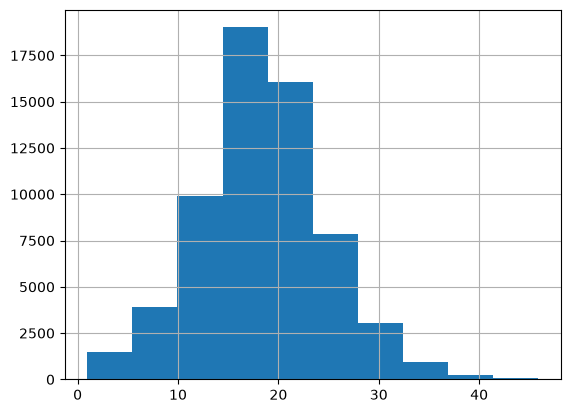

In [93]:
hgb_sd.hist()

In [94]:
np.percentile(hgb_sd, 1)

3.6319652355952012

In [95]:
# Some SDs are super super small! They make anemia not computable
hgb_sd = hgb_sd.clip(lower=np.percentile(hgb_sd, 1))

In [96]:
zero_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_zero_fort.rename("mean"), hgb_sd
)
zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.078383  0.402369   
                                            draw_1    0.112476  0.461056   
                                            draw_2    0.196059  0.477270   
                                            draw_3    0.048317  0.478881   
                                            draw_4    0.196998  0.460371   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.006195  0.146174   
                                            draw_246  0.000743  0.041820   
                                            draw_247  0.003738  0.135248   
                                            draw_248  0.001433  0.094509   
                                            draw_249  0.014129  0.347388   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199366  0.680119  
                                            draw_1    0.193205  0.766738  
                                            draw_2    0.157811  0.831140  
                                            draw_3    0.253794  0.780991  
                                            draw_4    0.156124  0.813493  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.494256  0.646626  
                                            draw_246  0.469756  0.512319  
                                            draw_247  0.568738  0.707725  
                                            draw_248  0.639011  0.734953  
                                            draw_249  0.556370  0.917887  

[62500 rows x 4 columns]

In [97]:
with_baseline_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_with_baseline_fortification.rename("mean"), hgb_sd
)
with_baseline_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.078383  0.402369   
                                            draw_1    0.112476  0.461056   
                                            draw_2    0.196059  0.477270   
                                            draw_3    0.048317  0.478881   
                                            draw_4    0.196998  0.460371   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.006195  0.146174   
                                            draw_246  0.000743  0.041820   
                                            draw_247  0.003738  0.135248   
                                            draw_248  0.001433  0.094509   
                                            draw_249  0.014129  0.347388   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199366  0.680119  
                                            draw_1    0.193205  0.766738  
                                            draw_2    0.157811  0.831140  
                                            draw_3    0.253794  0.780991  
                                            draw_4    0.156124  0.813493  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.494256  0.646626  
                                            draw_246  0.469756  0.512319  
                                            draw_247  0.568738  0.707725  
                                            draw_248  0.639011  0.734953  
                                            draw_249  0.556370  0.917887  

[62500 rows x 4 columns]

In [98]:
with_intervention_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(
    hgb_mean_with_intervention_fortification.rename("mean"), hgb_sd
)
with_intervention_fort_anemia

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                         
Female 0.0       0.019178   1               draw_0   intervention_25_nrv   0.078383   
                                                     intervention_100_nrv  0.078383   
                                            draw_1   intervention_25_nrv   0.112476   
                                                     intervention_100_nrv  0.112476   
                                            draw_2   intervention_25_nrv   0.196059   
...                                                                             ...   
Male   95.0      125.000000 5               draw_247 intervention_100_nrv  0.003738   
                                            draw_248 intervention_25_nrv   0.001433   
                                                     intervention_100_nrv  0.001433   
                                            draw_249 intervention_25_nrv   0.014129   
                                                     intervention_100_nrv  0.014129   

                                                                           moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                         
Female 0.0       0.019178   1               draw_0   intervention_25_nrv   0.402369   
                                                     intervention_100_nrv  0.402369   
                                            draw_1   intervention_25_nrv   0.461056   
                                                     intervention_100_nrv  0.461056   
                                            draw_2   intervention_25_nrv   0.477270   
...                                                                             ...   
Male   95.0      125.000000 5               draw_247 intervention_100_nrv  0.135248   
                                            draw_248 intervention_25_nrv   0.094509   
                                                     intervention_100_nrv  0.094509   
                                            draw_249 intervention_25_nrv   0.347388   
                                                     intervention_100_nrv  0.347388   

                                                                               mild  \
sex    age_start age_end    wealth_quintile draw     scenario                         
Female 0.0       0.019178   1               draw_0   intervention_25_nrv   0.199366   
                                                     intervention_100_nrv  0.199366   
                                            draw_1   intervention_25_nrv   0.193205   
                                                     intervention_100_nrv  0.193205   
                                            draw_2   intervention_25_nrv   0.157811   
...                                                                             ...   
Male   95.0      125.000000 5               draw_247 intervention_100_nrv  0.568738   
                                            draw_248 intervention_25_nrv   0.639011   
                                                     intervention_100_nrv  0.639011   
                                            draw_249 intervention_25_nrv   0.556370   
                                                     intervention_100_nrv  0.556370   

                                                                             anemic  
sex    age_start age_end    wealth_quintile draw     scenario                        
Female 0.0       0.019178   1               draw_0   intervention_25_nrv   0.680119  
                                                     intervention_100_nrv  0.680119  
                                            draw_1   intervention_25_nrv   0.766738  
                                                     intervention_100_nrv  0.766738  
                                            draw_2   intervention_25_nrv   0.831140  
...                                                                            

In [99]:
total_population_anemia = calculate_anemia_from_mean_sd_hemoglobin(hgb_mean, hgb_sd)
total_population_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.078383  0.402369   
                                            draw_1    0.112476  0.461056   
                                            draw_2    0.196059  0.477270   
                                            draw_3    0.048317  0.478881   
                                            draw_4    0.196998  0.460371   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.006195  0.146174   
                                            draw_246  0.000743  0.041820   
                                            draw_247  0.003738  0.135248   
                                            draw_248  0.001433  0.094509   
                                            draw_249  0.014129  0.347388   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199366  0.680119  
                                            draw_1    0.193205  0.766738  
                                            draw_2    0.157811  0.831140  
                                            draw_3    0.253794  0.780991  
                                            draw_4    0.156124  0.813493  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.494256  0.646626  
                                            draw_246  0.469756  0.512319  
                                            draw_247  0.568738  0.707725  
                                            draw_248  0.639011  0.734953  
                                            draw_249  0.556370  0.917887  

[62500 rows x 4 columns]

In [100]:
# NOTE: Here, we assume everyone is folate-responsive, instead of splitting this effect into
# a bigger effect among the folate-responsive and 0 among the non-

In [101]:
baseline_anemia = zero_fort_anemia.mul(
    (1 - effective_coverage_baseline), axis=0
) + with_baseline_fort_anemia.mul(
    effective_coverage_baseline, axis=0
)
baseline_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.078383  0.402369   
                                            draw_1    0.112476  0.461056   
                                            draw_2    0.196059  0.477270   
                                            draw_3    0.048317  0.478881   
                                            draw_4    0.196998  0.460371   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.006195  0.146174   
                                            draw_246  0.000743  0.041820   
                                            draw_247  0.003738  0.135248   
                                            draw_248  0.001433  0.094509   
                                            draw_249  0.014129  0.347388   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199366  0.680119  
                                            draw_1    0.193205  0.766738  
                                            draw_2    0.157811  0.831140  
                                            draw_3    0.253794  0.780991  
                                            draw_4    0.156124  0.813493  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.494256  0.646626  
                                            draw_246  0.469756  0.512319  
                                            draw_247  0.568738  0.707725  
                                            draw_248  0.639011  0.734953  
                                            draw_249  0.556370  0.917887  

[62500 rows x 4 columns]

In [102]:
(baseline_anemia - total_population_anemia).describe()

,severe,moderate,mild,anemic
count,62500.0,62500.0,62500.0,62500.0
mean,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0


In [103]:
(
    baseline_anemia.loc[example_tuple].mean()
    - with_intervention_fort_anemia.loc[example_tuple].mean()
) / baseline_anemia.loc[example_tuple].mean()

severe      0.246805
moderate    0.213928
mild        0.131803
anemic      0.185091
dtype: float64

In [104]:
zero_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.078383  0.402369   
                                            draw_1    0.112476  0.461056   
                                            draw_2    0.196059  0.477270   
                                            draw_3    0.048317  0.478881   
                                            draw_4    0.196998  0.460371   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.006195  0.146174   
                                            draw_246  0.000743  0.041820   
                                            draw_247  0.003738  0.135248   
                                            draw_248  0.001433  0.094509   
                                            draw_249  0.014129  0.347388   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.199366  0.680119  
                                            draw_1    0.193205  0.766738  
                                            draw_2    0.157811  0.831140  
                                            draw_3    0.253794  0.780991  
                                            draw_4    0.156124  0.813493  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.494256  0.646626  
                                            draw_246  0.469756  0.512319  
                                            draw_247  0.568738  0.707725  
                                            draw_248  0.639011  0.734953  
                                            draw_249  0.556370  0.917887  

[62500 rows x 4 columns]

In [105]:
intervention_anemia = zero_fort_anemia.mul(
    (1 - effective_coverage_intervention),
    axis=0,
) + with_intervention_fort_anemia.mul(effective_coverage_intervention, axis=0)
intervention_anemia

severe  \
sex    age_start age_end    wealth_quintile draw    scenario                         
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.078383   
                                                    intervention_25_nrv   0.078383   
                                            draw_1  intervention_100_nrv  0.112476   
                                                    intervention_25_nrv   0.112476   
                                            draw_10 intervention_100_nrv  0.216932   
...                                                                            ...   
Male   95.0      125.000000 5               draw_97 intervention_25_nrv   0.021349   
                                            draw_98 intervention_100_nrv  0.008277   
                                                    intervention_25_nrv   0.008277   
                                            draw_99 intervention_100_nrv  0.000114   
                                                    intervention_25_nrv   0.000114   

                                                                          moderate  \
sex    age_start age_end    wealth_quintile draw    scenario                         
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.402369   
                                                    intervention_25_nrv   0.402369   
                                            draw_1  intervention_100_nrv  0.461056   
                                                    intervention_25_nrv   0.461056   
                                            draw_10 intervention_100_nrv  0.464907   
...                                                                            ...   
Male   95.0      125.000000 5               draw_97 intervention_25_nrv   0.360579   
                                            draw_98 intervention_100_nrv  0.129529   
                                                    intervention_25_nrv   0.129529   
                                            draw_99 intervention_100_nrv  0.049462   
                                                    intervention_25_nrv   0.049462   

                                                                              mild  \
sex    age_start age_end    wealth_quintile draw    scenario                         
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.199366   
                                                    intervention_25_nrv   0.199366   
                                            draw_1  intervention_100_nrv  0.193205   
                                                    intervention_25_nrv   0.193205   
                                            draw_10 intervention_100_nrv  0.149480   
...                                                                            ...   
Male   95.0      125.000000 5               draw_97 intervention_25_nrv   0.514155   
                                            draw_98 intervention_100_nrv  0.396641   
                                                    intervention_25_nrv   0.396641   
                                            draw_99 intervention_100_nrv  0.868899   
                                                    intervention_25_nrv   0.868899   

                                                                            anemic  
sex    age_start age_end    wealth_quintile draw    scenario                        
Female 0.0       0.019178   1               draw_0  intervention_100_nrv  0.680119  
                                                    intervention_25_nrv   0.680119  
                                            draw_1  intervention_100_nrv  0.766738  
                                                    intervention_25_nrv   0.766738  
                                            draw_10 intervention_100_nrv  0.831319  
...                                                                            ...  
Male   95.0      125.000000 5          

In [106]:
from lsff_utils.hemoglobin_distribution import hemoglobin_pdf_from_mean_sd

In [107]:
total_population_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
total_population_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [108]:
zero_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_zero_fort.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
zero_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [109]:
with_baseline_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_with_baseline_fortification.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
with_baseline_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [110]:
with_intervention_fort_pdf = hemoglobin_pdf_from_mean_sd(
    np.array([hgb_mean_with_intervention_fortification.loc[example_tuple].mean()]),
    np.array([hgb_sd.loc[example_tuple].mean()]),
)
with_intervention_fort_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [111]:
def baseline_pdf(x):
    effective_covered = effective_coverage_baseline.loc[example_tuple]
    return (
        zero_fort_pdf(x) * (1 - effective_covered)
        + with_baseline_fort_pdf(x) * effective_covered
    )

In [112]:
def intervention_pdf(x):
    effective_covered = effective_coverage_intervention.loc[example_tuple]
    return (
        zero_fort_pdf(x) * (1 - effective_covered)
        + with_intervention_fort_pdf(x) * effective_covered
    )

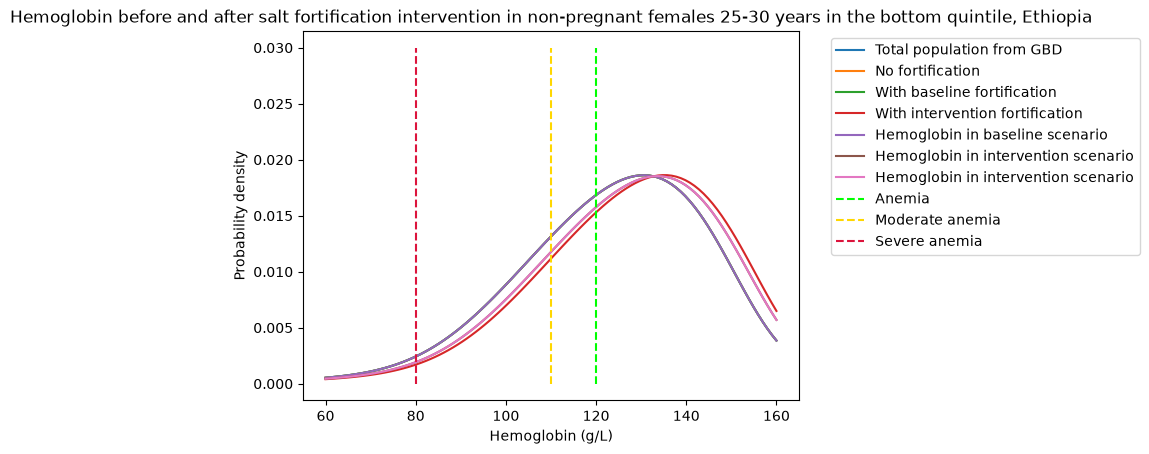

In [113]:
import matplotlib.pyplot as plt

x_values = np.linspace(60, 160, 100)
with np.errstate(under="ignore"):
    plt.plot(
        x_values,
        [total_population_pdf(x) for x in x_values],
        label="Total population from GBD",
    )
    plt.plot(
        x_values,
        [zero_fort_pdf(x) for x in x_values],
        label="No fortification",
    )
    plt.plot(
        x_values,
        [with_baseline_fort_pdf(x) for x in x_values],
        label="With baseline fortification",
    )
    plt.plot(
        x_values,
        [with_intervention_fort_pdf(x) for x in x_values],
        label="With intervention fortification",
    )
    plt.plot(
        x_values,
        [baseline_pdf(x) for x in x_values],
        label="Hemoglobin in baseline scenario",
    )
    plt.plot(
        x_values,
        [intervention_pdf(x) for x in x_values],
        label="Hemoglobin in intervention scenario",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_mild,
        0,
        0.03,
        linestyles="dashed",
        label="Anemia",
        color="lime",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_moderate,
        0,
        0.03,
        linestyles="dashed",
        label="Moderate anemia",
        color="gold",
    )
    plt.vlines(
        thresholds.loc[
            (example_sex, example_age_start, example_age_end, 0)
        ].hgb_upper_severe,
        0,
        0.03,
        linestyles="dashed",
        label="Severe anemia",
        color="crimson",
    )
    plt.xlabel("Hemoglobin (g/L)")
    plt.ylabel("Probability density")
    plt.title(
        f"Hemoglobin before and after {vehicle} fortification intervention in non-pregnant females 25-30 years in the bottom quintile, {location.title()}"
    )
    plt.legend(bbox_to_anchor=(1.05, 1))

In [114]:
(baseline_anemia - intervention_anemia).sort_values("anemic")

severe  \
sex    age_start age_end   wealth_quintile draw     scenario                             
Female 0.019178  0.076712  2               draw_21  intervention_100_nrv  0.000000e+00   
                                                    intervention_25_nrv   0.000000e+00   
                                           draw_192 intervention_100_nrv  0.000000e+00   
                                                    intervention_25_nrv   0.000000e+00   
                                           draw_163 intervention_100_nrv -3.469447e-18   
...                                                                                ...   
       35.000000 40.000000 3               draw_158 intervention_100_nrv  1.325104e-03   
       40.000000 45.000000 2               draw_158 intervention_100_nrv  1.077163e-03   
                           1               draw_89  intervention_100_nrv  1.471038e-03   
                                           draw_188 intervention_100_nrv  1.102131e-03   
                           3               draw_158 intervention_100_nrv  9.231665e-04   

                                                                              moderate  \
sex    age_start age_end   wealth_quintile draw     scenario                             
Female 0.019178  0.076712  2               draw_21  intervention_100_nrv  0.000000e+00   
                                                    intervention_25_nrv   0.000000e+00   
                                           draw_192 intervention_100_nrv  5.551115e-17   
                                                    intervention_25_nrv   5.551115e-17   
                                           draw_163 intervention_100_nrv  5.551115e-17   
...                                                                                ...   
       35.000000 40.000000 3               draw_158 intervention_100_nrv  6.091326e-02   
       40.000000 45.000000 2               draw_158 intervention_100_nrv  6.219742e-02   
                           1               draw_89  intervention_100_nrv  7.285676e-02   
                                           draw_188 intervention_100_nrv  6.820064e-02   
                           3               draw_158 intervention_100_nrv  5.838545e-02   

                                                                              mild  \
sex    age_start age_end   wealth_quintile draw     scenario                         
Female 0.019178  0.076712  2               draw_21  intervention_100_nrv  0.000000   
                                                    intervention_25_nrv   0.000000   
                                           draw_192 intervention_100_nrv  0.000000   
                                                    intervention_25_nrv   0.000000   
                                           draw_163 intervention_100_nrv  0.000000   
...                                                                            ...   
       35.000000 40.000000 3               draw_158 intervention_100_nrv  0.090472   
       40.000000 45.000000 2               draw_158 intervention_100_nrv  0.092568   
                           1               draw_89  intervention_100_nrv  0.081820   
                                           draw_188 intervention_100_nrv  0.091258   
                           3               draw_158 intervention_100_nrv  0.104980   

                                                                                anemic  
sex    age_start age_end   wealth_quintile draw     scenario                            
Female 0.019178  0.076712  2               draw_21  intervention_100_nrv -1.110223e-16  
                                                    intervention_25_nrv  -1.110223e-16  
                                           draw_192 intervention_100_nrv -1.110223e-16  
                                                    intervention_25_nrv  -1.110223e-16  
                                           draw_163 intervention_100_nrv -1.110223e-1

In [115]:
def anemia_to_yld_rates(anemia):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia.index
    anemia = (
        anemia.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia["mild_yld_rate"] = anemia.mild * anemia.mild_dw
    anemia["moderate_yld_rate"] = anemia.moderate * anemia.moderate_dw
    anemia["severe_yld_rate"] = anemia.severe * anemia.severe_dw
    anemia["anemic_yld_rate"] = (
        anemia["mild_yld_rate"]
        + anemia["moderate_yld_rate"]
        + anemia["severe_yld_rate"]
    )

    return anemia.set_index(orig_index.names).filter(like="yld_rate")

In [116]:
zero_fort_anemia_yld_rates = anemia_to_yld_rates(zero_fort_anemia)
zero_fort_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000483   
                            2               draw_0         0.000552   
                            3               draw_0         0.000548   
                            4               draw_0         0.000608   
                            5               draw_0         0.000574   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.002116   
                            2               draw_249       0.002520   
                            3               draw_249       0.002622   
                            4               draw_249       0.002742   
                            5               draw_249       0.002961   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.023861   
                            2               draw_0             0.021144   
                            3               draw_0             0.017874   
                            4               draw_0             0.019900   
                            5               draw_0             0.015200   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.034030   
                            2               draw_249           0.031372   
                            3               draw_249           0.030132   
                            4               draw_249           0.028651   
                            5               draw_249           0.025641   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.015594   
                            2               draw_0           0.007636   
                            3               draw_0           0.005169   
                            4               draw_0           0.004893   
                            5               draw_0           0.003073   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.012155   
                            2               draw_249         0.005822   
                            3               draw_249         0.004881   
                            4               draw_249         0.003945   
                            5               draw_249         0.002669   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.039937  
                            2               draw_0           0.029332  
                            3               draw_0           0.023590  
                            4               draw_0           0.025401  
                            5               draw_0           0.018847  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.048301  
                            2               draw_249         0.039715  
                            3               draw_249         0.037634  
                            4               draw_249         0.035339  
                            5               draw_249         0.031272  

[62500 rows x 4 columns]

In [117]:
baseline_anemia_yld_rates = anemia_to_yld_rates(baseline_anemia)
baseline_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000483   
                            2               draw_0         0.000552   
                            3               draw_0         0.000548   
                            4               draw_0         0.000608   
                            5               draw_0         0.000574   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.002116   
                            2               draw_249       0.002520   
                            3               draw_249       0.002622   
                            4               draw_249       0.002742   
                            5               draw_249       0.002961   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.023861   
                            2               draw_0             0.021144   
                            3               draw_0             0.017874   
                            4               draw_0             0.019900   
                            5               draw_0             0.015200   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.034030   
                            2               draw_249           0.031372   
                            3               draw_249           0.030132   
                            4               draw_249           0.028651   
                            5               draw_249           0.025641   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.015594   
                            2               draw_0           0.007636   
                            3               draw_0           0.005169   
                            4               draw_0           0.004893   
                            5               draw_0           0.003073   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.012155   
                            2               draw_249         0.005822   
                            3               draw_249         0.004881   
                            4               draw_249         0.003945   
                            5               draw_249         0.002669   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.039937  
                            2               draw_0           0.029332  
                            3               draw_0           0.023590  
                            4               draw_0           0.025401  
                            5               draw_0           0.018847  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.048301  
                            2               draw_249         0.039715  
                            3               draw_249         0.037634  
                            4               draw_249         0.035339  
                            5               draw_249         0.031272  

[62500 rows x 4 columns]

In [118]:
(
    baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()
    - anemia_to_yld_rates(with_intervention_fort_anemia).loc[("Female", 25, 30, 1)].mean()
) / baseline_anemia_yld_rates.loc[("Female", 25, 30, 1)].mean()

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate        0.131972
moderate_yld_rate    0.213987
severe_yld_rate      0.247054
anemic_yld_rate      0.221339
dtype: float64

In [119]:
intervention_anemia_yld_rates = anemia_to_yld_rates(intervention_anemia)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                              
Female 0.0       0.019178   1               draw_0  intervention_100_nrv       0.000483   
                                                    intervention_25_nrv        0.000483   
                            2               draw_0  intervention_100_nrv       0.000552   
                                                    intervention_25_nrv        0.000552   
                            3               draw_0  intervention_100_nrv       0.000548   
...                                                                                 ...   
Male   95.0      125.000000 3               draw_99 intervention_25_nrv        0.003561   
                            4               draw_99 intervention_100_nrv       0.003622   
                                                    intervention_25_nrv        0.003622   
                            5               draw_99 intervention_100_nrv       0.003650   
                                                    intervention_25_nrv        0.003650   

                                                                          moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                                  
Female 0.0       0.019178   1               draw_0  intervention_100_nrv           0.023861   
                                                    intervention_25_nrv            0.023861   
                            2               draw_0  intervention_100_nrv           0.021144   
                                                    intervention_25_nrv            0.021144   
                            3               draw_0  intervention_100_nrv           0.017874   
...                                                                                     ...   
Male   95.0      125.000000 3               draw_99 intervention_25_nrv            0.004480   
                            4               draw_99 intervention_100_nrv           0.003468   
                                                    intervention_25_nrv            0.003468   
                            5               draw_99 intervention_100_nrv           0.002062   
                                                    intervention_25_nrv            0.002062   

                                                                          severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw    scenario                                
Female 0.0       0.019178   1               draw_0  intervention_100_nrv         0.015594   
                                                    intervention_25_nrv          0.015594   
                            2               draw_0  intervention_100_nrv         0.007636   
                                                    intervention_25_nrv          0.007636   
                            3               draw_0  intervention_100_nrv         0.005169   
...                                                                                   ...   
Male   95.0      125.000000 3               draw_99 intervention_25_nrv          0.000045   
                            4               draw_99 intervention_100_nrv         0.000030   
                                                    intervention_25_nrv          0.000030   
                            5               draw_99 intervention_100_nrv         0.000014   
                                                    intervention_25_nrv          0.000014   

                                                                          anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw    scenario                               
Female 0.0       0.019178   1               draw_0  intervention_100_nrv         0.039937  
                                                    intervention_25_nrv          0.039937  
                            2               draw_0  intervention_100_nrv    

In [120]:
(baseline_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end wealth_quintile draw     scenario                              
Male   95.0      125.0   1               draw_172 intervention_100_nrv       0.000000   
                                                  intervention_25_nrv        0.000000   
Female 90.0      95.0    2               draw_78  intervention_100_nrv       0.000000   
                                                  intervention_25_nrv        0.000000   
Male   2.0       5.0     1               draw_249 intervention_100_nrv       0.000000   
...                                                                               ...   
Female 35.0      40.0    1               draw_78  intervention_100_nrv       0.000074   
       40.0      45.0    1               draw_89  intervention_100_nrv       0.000570   
                                         draw_78  intervention_100_nrv       0.000079   
       25.0      30.0    1               draw_45  intervention_100_nrv       0.000286   
       30.0      35.0    1               draw_45  intervention_100_nrv       0.000289   

                                                                        moderate_yld_rate  \
sex    age_start age_end wealth_quintile draw     scenario                                  
Male   95.0      125.0   1               draw_172 intervention_100_nrv      -6.938894e-18   
                                                  intervention_25_nrv       -6.938894e-18   
Female 90.0      95.0    2               draw_78  intervention_100_nrv       0.000000e+00   
                                                  intervention_25_nrv        0.000000e+00   
Male   2.0       5.0     1               draw_249 intervention_100_nrv      -6.938894e-18   
...                                                                                   ...   
Female 35.0      40.0    1               draw_78  intervention_100_nrv       4.662094e-03   
       40.0      45.0    1               draw_89  intervention_100_nrv       5.644694e-03   
                                         draw_78  intervention_100_nrv       4.839827e-03   
       25.0      30.0    1               draw_45  intervention_100_nrv       5.135850e-03   
       30.0      35.0    1               draw_45  intervention_100_nrv       5.170642e-03   

                                                                        severe_yld_rate  \
sex    age_start age_end wealth_quintile draw     scenario                                
Male   95.0      125.0   1               draw_172 intervention_100_nrv     0.000000e+00   
                                                  intervention_25_nrv      0.000000e+00   
Female 90.0      95.0    2               draw_78  intervention_100_nrv    -3.469447e-18   
                                                  intervention_25_nrv     -3.469447e-18   
Male   2.0       5.0     1               draw_249 intervention_100_nrv     0.000000e+00   
...                                                                                 ...   
Female 35.0      40.0    1               draw_78  intervention_100_nrv     1.718094e-03   
       40.0      45.0    1               draw_89  intervention_100_nrv     2.791943e-04   
                                         draw_78  intervention_100_nrv     1.614678e-03   
       25.0      30.0    1               draw_45  intervention_100_nrv     1.280228e-03   
       30.0      35.0    1               draw_45  intervention_100_nrv     1.273072e-03   

                                                                        anemic_yld_rate  
sex    age_start age_end wealth_quintile draw     scenario                               
Male   95.0      125.0   1               draw_172 intervention_100_nrv    -1.387779e-17  
                                                  intervention_25_nrv     -1.387779e-17  
Female 90.0      95.0    2               draw_78  intervention_100_nrv    -1.387779e-17  
                                                  intervention_25_nrv 

In [121]:
(baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate.describe()

count    1.250000e+05
mean     3.167827e-04
std      7.952666e-04
min     -1.387779e-17
25%      0.000000e+00
50%      0.000000e+00
75%      1.575295e-04
max      6.732638e-03
Name: anemic_yld_rate, dtype: float64

In [122]:
assert (
    ((baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate >= 0)
    | np.isclose(
        (baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate, 0
    )
).all()

In [123]:
zero_fort_ylds = (
    zero_fort_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  384.312386
                               2                  285.150179
                               3                  230.360898
                               4                  221.901969
                               5                  143.476230
                                                     ...    
Male    95.0       125.000000  1                   37.178558
                               2                   27.494390
                               3                   25.996314
                               4                   24.739751
                               5                   17.905273
Length: 250, dtype: float64

In [124]:
baseline_ylds = (
    baseline_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  384.312386
                               2                  285.150179
                               3                  230.360898
                               4                  221.901969
                               5                  143.476230
                                                     ...    
Male    95.0       125.000000  1                   37.178558
                               2                   27.494390
                               3                   25.996314
                               4                   24.739751
                               5                   17.905273
Length: 250, dtype: float64

In [125]:
intervention_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_ylds

sex     age_start  age_end     wealth_quintile  scenario            
Female  0.0        0.019178    1                intervention_100_nrv    384.312386
                                                intervention_25_nrv     384.312386
                               2                intervention_100_nrv    285.150179
                                                intervention_25_nrv     285.150179
                               3                intervention_100_nrv    230.360898
                                                                           ...    
Male    95.0       125.000000  3                intervention_25_nrv      25.996314
                               4                intervention_100_nrv     24.739751
                                                intervention_25_nrv      24.739751
                               5                intervention_100_nrv     17.905273
                                                intervention_25_nrv      17.905273
Length: 500, dtype

In [126]:
(
    baseline_ylds.loc[("Female", 25, 30, 1)]
    - intervention_ylds.loc[("Female", 25, 30, 1)]
)

scenario
intervention_100_nrv    2443.424461
intervention_25_nrv      690.724687
dtype: float64

In [127]:
(
    baseline_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_ylds.groupby(["wealth_quintile", "scenario"]).sum()
)

wealth_quintile  scenario            
1                intervention_100_nrv    24236.893316
                 intervention_25_nrv      6931.603770
2                intervention_100_nrv    19962.540095
                 intervention_25_nrv      6008.397320
3                intervention_100_nrv    21288.498011
                 intervention_25_nrv      6648.335109
4                intervention_100_nrv     9462.193079
                 intervention_25_nrv      2593.667459
5                intervention_100_nrv     7307.984633
                 intervention_25_nrv      1962.862392
dtype: float64

In [128]:
ylds = pd.concat(
    [
        zero_fort_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_ylds.rename("value").reset_index().assign(scenario="baseline"),
        intervention_ylds.rename("value").reset_index(),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,384.312386,zero
1,Female,0.0,0.019178,2,285.150179,zero
2,Female,0.0,0.019178,3,230.360898,zero
3,Female,0.0,0.019178,4,221.901969,zero
4,Female,0.0,0.019178,5,143.476230,zero
...,...,...,...,...,...,...
995,Male,95.0,125.000000,3,25.996314,intervention_25_nrv
996,Male,95.0,125.000000,4,24.739751,intervention_100_nrv
997,Male,95.0,125.000000,4,24.739751,intervention_25_nrv
998,Male,95.0,125.000000,5,17.905273,intervention_100_nrv


In [129]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [130]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [131]:
zero_fort_anemia_prevalence = zero_fort_anemia["anemic"].unstack("draw").mean(axis=1)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.795184
                               2                  0.769543
                               3                  0.716797
                               4                  0.776773
                               5                  0.693838
                                                    ...   
Male    95.0       125.000000  1                  0.872545
                               2                  0.860459
                               3                  0.852947
                               4                  0.844409
                               5                  0.825380
Length: 250, dtype: float64

In [132]:
baseline_anemia_prevalence = baseline_anemia["anemic"].unstack("draw").mean(axis=1)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.795184
                               2                  0.769543
                               3                  0.716797
                               4                  0.776773
                               5                  0.693838
                                                    ...   
Male    95.0       125.000000  1                  0.872545
                               2                  0.860459
                               3                  0.852947
                               4                  0.844409
                               5                  0.825380
Length: 250, dtype: float64

In [133]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  6449.456996
                               2                  5673.621278
                               3                  4996.143269
                               4                  4855.422690
                               5                  3476.349616
                                                     ...     
Male    95.0       125.000000  1                  1273.509355
                               2                  1313.983178
                               3                  1351.943643
                               4                  1416.157301
                               5                  1213.147337
Length: 250, dtype: float64

In [134]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.3063056584126018

In [135]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  6449.456996
                               2                  5673.621278
                               3                  4996.143269
                               4                  4855.422690
                               5                  3476.349616
                                                     ...     
Male    95.0       125.000000  1                  1273.509355
                               2                  1313.983178
                               3                  1351.943643
                               4                  1416.157301
                               5                  1213.147337
Length: 250, dtype: float64

In [136]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.3063056584126018

In [137]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.429864
2    0.330852
3    0.290660
4    0.274712
5    0.214322
dtype: float64

In [138]:
intervention_anemia_prevalence = (
    intervention_anemia["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario            
Female  0.0        0.019178    1                intervention_100_nrv    0.795184
                                                intervention_25_nrv     0.795184
                               2                intervention_100_nrv    0.769543
                                                intervention_25_nrv     0.769543
                               3                intervention_100_nrv    0.716797
                                                                          ...   
Male    95.0       125.000000  3                intervention_25_nrv     0.852947
                               4                intervention_100_nrv    0.844409
                                                intervention_25_nrv     0.844409
                               5                intervention_100_nrv    0.825380
                                                intervention_25_nrv     0.825380
Length: 500, dtype: float64

In [139]:
total_population_anemia_prevalence = (
    total_population_anemia["anemic"].unstack("draw").mean(axis=1)
)
total_population_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.795184
                               2                  0.769543
                               3                  0.716797
                               4                  0.776773
                               5                  0.693838
                                                    ...   
Male    95.0       125.000000  1                  0.872545
                               2                  0.860459
                               3                  0.852947
                               4                  0.844409
                               5                  0.825380
Length: 250, dtype: float64

In [140]:
total_population_anemia_cases = total_population_anemia_prevalence.mul(
    non_pregnant_pop, axis=0
)
total_population_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  6449.456996
                               2                  5673.621278
                               3                  4996.143269
                               4                  4855.422690
                               5                  3476.349616
                                                     ...     
Male    95.0       125.000000  1                  1273.509355
                               2                  1313.983178
                               3                  1351.943643
                               4                  1416.157301
                               5                  1213.147337
Length: 250, dtype: float64

In [141]:
total_population_anemia_cases.sum() / non_pregnant_pop.sum()

0.3063056584126018

In [142]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.795184,zero
1,Female,0.0,0.019178,2,0.769543,zero
2,Female,0.0,0.019178,3,0.716797,zero
3,Female,0.0,0.019178,4,0.776773,zero
4,Female,0.0,0.019178,5,0.693838,zero
...,...,...,...,...,...,...
995,Male,95.0,125.000000,3,0.852947,intervention_25_nrv
996,Male,95.0,125.000000,4,0.844409,intervention_100_nrv
997,Male,95.0,125.000000,4,0.844409,intervention_25_nrv
998,Male,95.0,125.000000,5,0.825380,intervention_100_nrv


In [143]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [144]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario            
Female  0.0        0.019178    1                intervention_100_nrv    6449.456996
                                                intervention_25_nrv     6449.456996
                               2                intervention_100_nrv    5673.621278
                                                intervention_25_nrv     5673.621278
                               3                intervention_100_nrv    4996.143269
                                                                           ...     
Male    95.0       125.000000  3                intervention_25_nrv     1351.943643
                               4                intervention_100_nrv    1416.157301
                                                intervention_25_nrv     1416.157301
                               5                intervention_100_nrv    1213.147337
                                                intervention_25_nrv     1213.147337
Length:

In [145]:
intervention_anemia_cases.groupby("scenario").sum() / non_pregnant_pop.sum()

scenario
intervention_100_nrv    0.281819
intervention_25_nrv     0.299462
dtype: float64

In [146]:
intervention_anemia_cases.groupby(
    ["scenario", "wealth_quintile"]
).sum() / non_pregnant_pop.groupby(["wealth_quintile"]).sum()

scenario              wealth_quintile
intervention_100_nrv  1                  0.401004
                      2                  0.299759
                      3                  0.255658
                      4                  0.259048
                      5                  0.201550
intervention_25_nrv   1                  0.422066
                      2                  0.322005
                      3                  0.280361
                      4                  0.270531
                      5                  0.210952
dtype: float64

In [147]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["scenario", "wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

scenario              wealth_quintile
intervention_100_nrv  1                  608,963
                      2                  667,328
                      3                  757,796
                      4                  345,145
                      5                  291,466
intervention_25_nrv   1                  164,538
                      2                  189,878
                      3                  222,967
                      4                   92,121
                      5                   76,902
dtype: object

In [148]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,6449.456996,zero
1,Female,0.0,0.019178,2,5673.621278,zero
2,Female,0.0,0.019178,3,4996.143269,zero
3,Female,0.0,0.019178,4,4855.422690,zero
4,Female,0.0,0.019178,5,3476.349616,zero
...,...,...,...,...,...,...
995,Male,95.0,125.000000,3,1351.943643,intervention_25_nrv
996,Male,95.0,125.000000,4,1416.157301,intervention_100_nrv
997,Male,95.0,125.000000,4,1416.157301,intervention_25_nrv
998,Male,95.0,125.000000,5,1213.147337,intervention_100_nrv


In [149]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)

In [150]:
anemia_cases.notnull().all()

sex                True
age_start          True
age_end            True
wealth_quintile    True
value              True
scenario           True
dtype: bool